In [9]:
import pandas as pd
import numpy as np

# Data para el DataFrame ficticio
data = {
    'Department': [
        'Antioquia', 'Cundinamarca', 'Valle del Cauca', 'Atlántico', 'Santander',
        'Antioquia', 'Cundinamarca', 'Valle del Cauca', 'Atlántico', 'Santander',
        'Nariño', 'Bolívar', 'Caldas', 'Meta', 'Boyacá',
        'Antioquia', 'Cundinamarca', 'Valle del Cauca', 'Atlántico', 'Santander',
        'Nariño', 'Bolívar', 'Caldas', 'Meta', 'Boyacá'
    ],
    'Vehicle_Type': [
        'Car', 'SUV', 'Car', 'Truck', 'SUV',
        'Car', 'SUV', 'Car', 'Truck', 'Car',
        'SUV', 'Car', 'Truck', 'SUV', 'Car',
        'Car', 'SUV', 'Truck', 'Car', 'SUV',
        'Car', 'SUV', 'Car', 'Truck', 'Car'
    ],
    'Brand': [
        'Chevrolet', 'Renault', 'Mazda', 'Toyota', 'Kia',
        'Hyundai', 'Nissan', 'Ford', 'Chevrolet', 'Renault',
        'Mazda', 'Toyota', 'Kia', 'Hyundai', 'Nissan',
        'Ford', 'Chevrolet', 'Renault', 'Mazda', 'Toyota',
        'Kia', 'Hyundai', 'Nissan', 'Ford', 'Chevrolet'
    ],
    'Value_USD': [
        25000, 35000, 30000, 50000, 40000,
        28000, 38000, 32000, 55000, 27000,
        42000, 31000, 48000, 39000, 26000,
        29000, 36000, 52000, 33000, 41000,
        np.nan, 30000, 51000, 49000, np.nan
    ],
    'Units_Sold_Monthly': [
        150, 120, 180, 70, 90,
        130, 110, 160, 60, 100,
        80, 140, 65, 95, 105,
        125, 115, np.nan, 170, 85,
        75, 135, 70, 55, np.nan
    ]
}

df_vehicles = pd.DataFrame(data)

# Introducir más valores nulos aleatoriamente para simular datos del mundo real
np.random.seed(42) # Para reproducibilidad
for col in ['Vehicle_Type', 'Brand']:
    df_vehicles.loc[df_vehicles.sample(frac=0.08).index, col] = np.nan

print("DataFrame ficticio creado:")
display(df_vehicles.head())


DataFrame ficticio creado:


,Department,Vehicle_Type,Brand,Value_USD,Units_Sold_Monthly
0,Antioquia,Car,Chevrolet,25000.0,150.0
1,Cundinamarca,SUV,Renault,35000.0,120.0
2,Valle del Cauca,Car,Mazda,30000.0,180.0
3,Atlántico,Truck,Toyota,50000.0,70.0
4,Santander,SUV,Kia,40000.0,90.0


### Análisis Exploratorio de Datos (EDA) del DataFrame `df_vehicles`

Ahora, realizaremos algunos pasos básicos de EDA para entender la estructura, tipos de datos y la presencia de valores nulos en nuestro DataFrame ficticio.

In [10]:
print("Información general del DataFrame:")
df_vehicles.info()

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Department          25 non-null     object 
 1   Vehicle_Type        23 non-null     object 
 2   Brand               23 non-null     object 
 3   Value_USD           23 non-null     float64
 4   Units_Sold_Monthly  23 non-null     float64
dtypes: float64(2), object(3)
memory usage: 1.1+ KB


In [11]:
print("\nRecuento de valores nulos por columna:")
display(df_vehicles.isnull().sum())


Recuento de valores nulos por columna:


,0
Department,0
Vehicle_Type,2
Brand,2
Value_USD,2
Units_Sold_Monthly,2


In [12]:
print("\nEstadísticas descriptivas para columnas numéricas:")
display(df_vehicles.describe())


Estadísticas descriptivas para columnas numéricas:


,Value_USD,Units_Sold_Monthly
count,23.000000,23.000000
mean,37695.652174,108.043478
std,9324.624207,36.329900
min,25000.000000,55.000000
25%,30000.000000,77.500000
50%,36000.000000,105.000000
75%,45000.000000,132.500000
max,55000.000000,180.000000


In [13]:
print("\nValores únicos y sus conteos para 'Department':")
display(df_vehicles['Department'].value_counts(dropna=False))

print("\nValores únicos y sus conteos para 'Vehicle_Type':")
display(df_vehicles['Vehicle_Type'].value_counts(dropna=False))

print("\nValores únicos y sus conteos para 'Brand':")
display(df_vehicles['Brand'].value_counts(dropna=False))


Valores únicos y sus conteos para 'Department':


,count
Department,
Antioquia,3
Cundinamarca,3
Valle del Cauca,3
Atlántico,3
Santander,3
Nariño,2
Bolívar,2
Caldas,2
Meta,2



Valores únicos y sus conteos para 'Vehicle_Type':


,count
Vehicle_Type,
Car,12
SUV,7
Truck,4
NaN,2



Valores únicos y sus conteos para 'Brand':


,count
Brand,
Chevrolet,4
Renault,3
Toyota,3
Kia,3
Nissan,3
Ford,3
Mazda,2
Hyundai,2
NaN,2


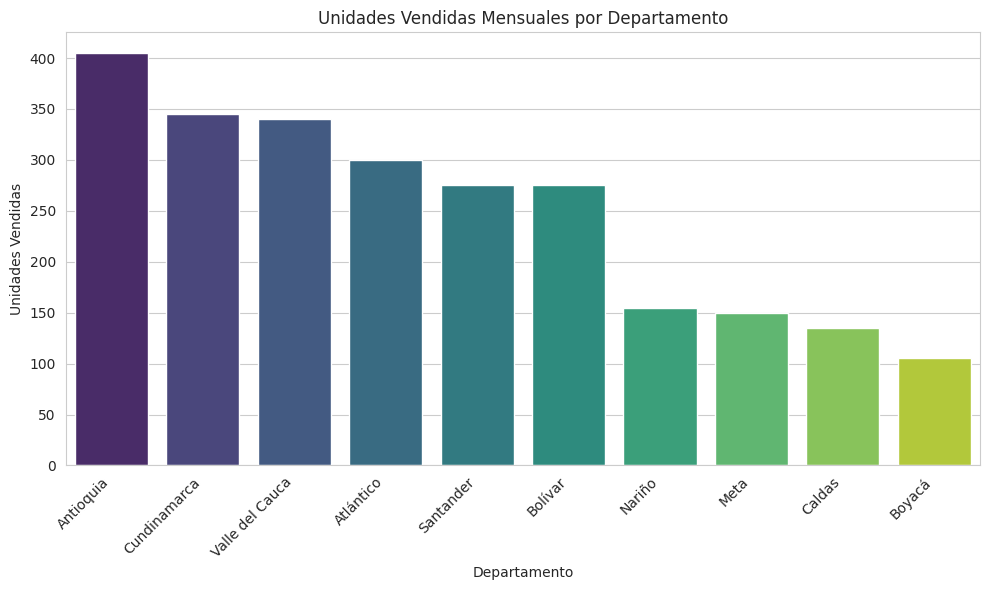

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para gráficos
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# 1. Ventas mensuales por Departamento
sales_by_department = df_vehicles.groupby('Department')['Units_Sold_Monthly'].sum().sort_values(ascending=False)
sns.barplot(x=sales_by_department.index, y=sales_by_department.values, hue=sales_by_department.index, palette='viridis', legend=False)
plt.title('Unidades Vendidas Mensuales por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

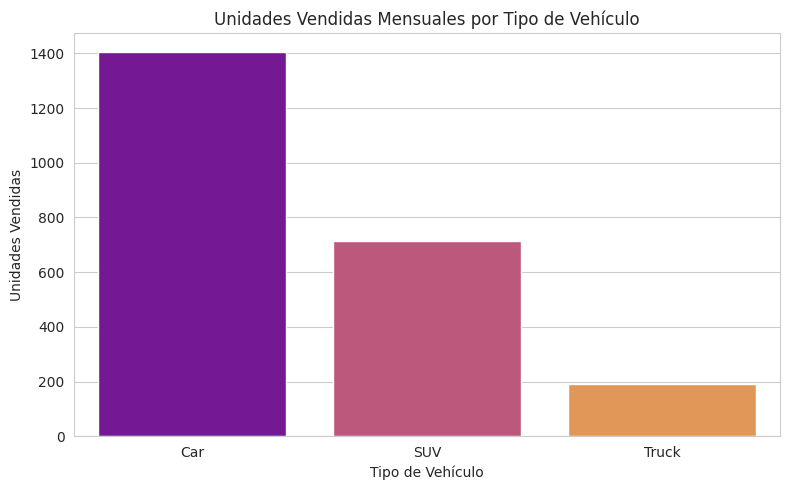

In [20]:
# 2. Ventas mensuales por Tipo de Vehículo
plt.figure(figsize=(8, 5))
sales_by_vehicle_type = df_vehicles.groupby('Vehicle_Type')['Units_Sold_Monthly'].sum().sort_values(ascending=False)
sns.barplot(x=sales_by_vehicle_type.index, y=sales_by_vehicle_type.values, hue=sales_by_vehicle_type.index, palette='plasma', legend=False)
plt.title('Unidades Vendidas Mensuales por Tipo de Vehículo')
plt.xlabel('Tipo de Vehículo')
plt.ylabel('Unidades Vendidas')
plt.tight_layout()
plt.show()

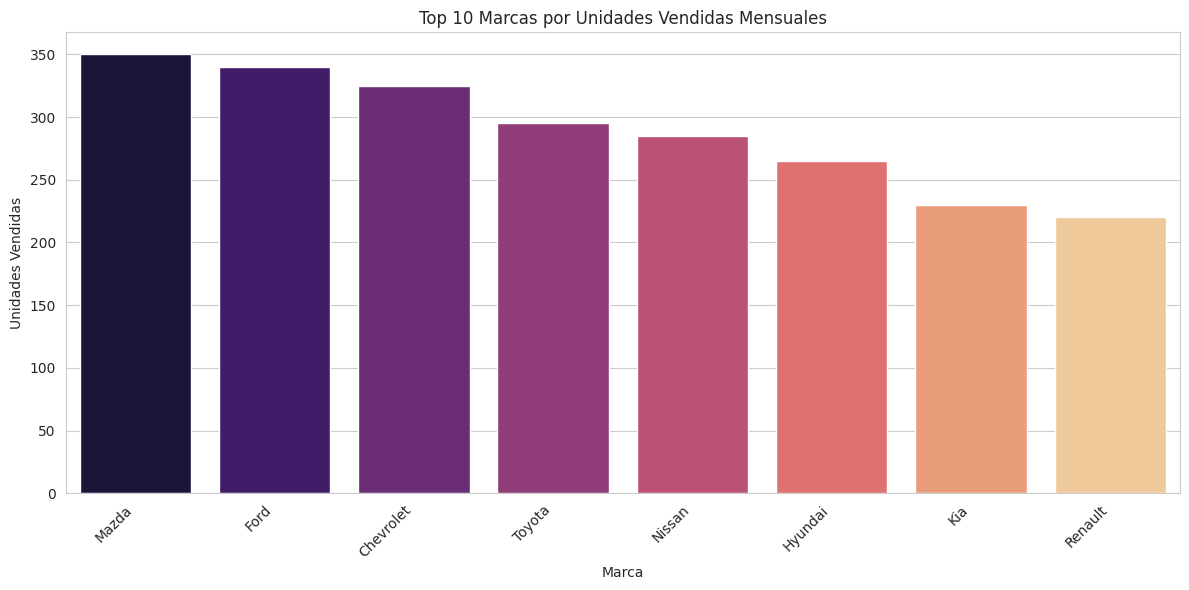

In [21]:
# 3. Ventas mensuales por Marca (Top 10)
plt.figure(figsize=(12, 6))
sales_by_brand = df_vehicles.groupby('Brand')['Units_Sold_Monthly'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=sales_by_brand.index, y=sales_by_brand.values, hue=sales_by_brand.index, palette='magma', legend=False)
plt.title('Top 10 Marcas por Unidades Vendidas Mensuales')
plt.xlabel('Marca')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

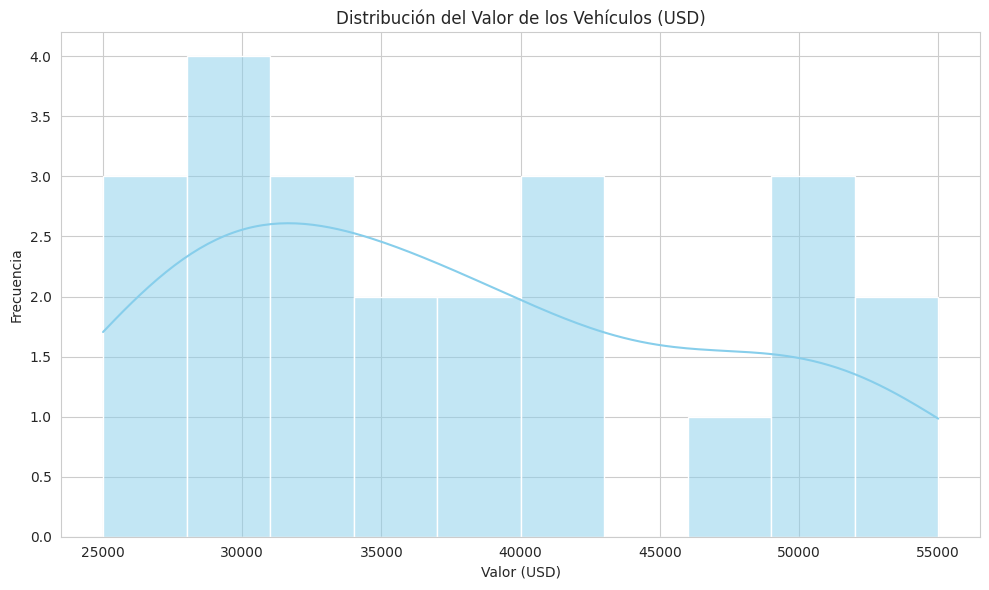

In [17]:
# 4. Distribución del Valor (USD) de los Vehículos
plt.figure(figsize=(10, 6))
sns.histplot(df_vehicles['Value_USD'].dropna(), bins=10, kde=True, color='skyblue')
plt.title('Distribución del Valor de los Vehículos (USD)')
plt.xlabel('Valor (USD)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

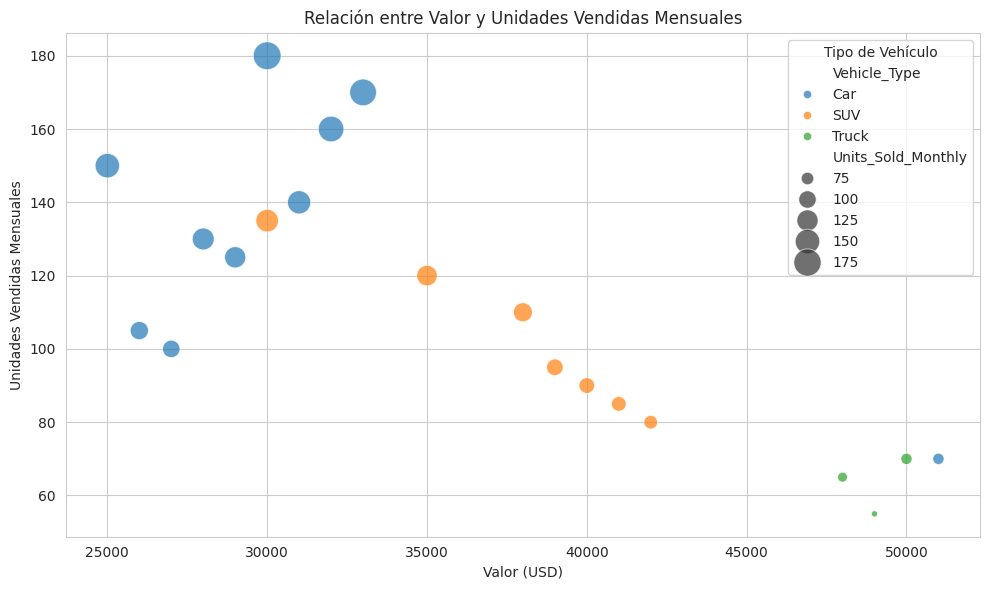

In [18]:
# 5. Relación entre Valor (USD) y Unidades Vendidas Mensuales
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Value_USD', y='Units_Sold_Monthly', hue='Vehicle_Type', data=df_vehicles.dropna(subset=['Value_USD', 'Units_Sold_Monthly', 'Vehicle_Type']), size='Units_Sold_Monthly', sizes=(20, 400), alpha=0.7)
plt.title('Relación entre Valor y Unidades Vendidas Mensuales')
plt.xlabel('Valor (USD)')
plt.ylabel('Unidades Vendidas Mensuales')
plt.legend(title='Tipo de Vehículo')
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

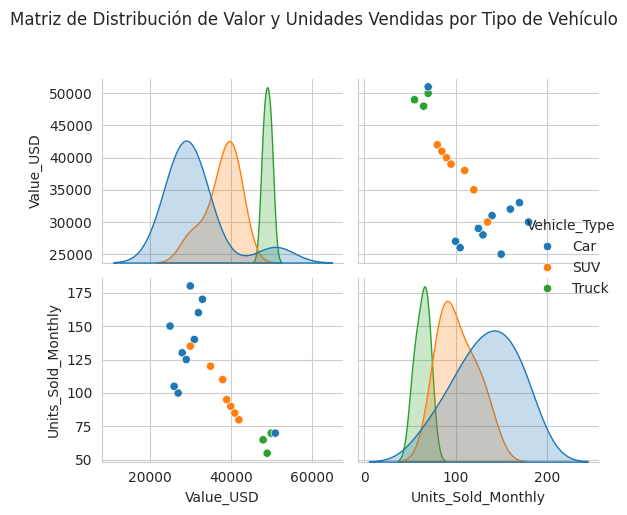

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de distribución (Pair Plot) para ver relaciones entre variables numéricas
# y la distribución de cada una, diferenciando por Vehicle_Type
plt.figure(figsize=(10, 8))
sns.pairplot(df_vehicles.dropna(subset=['Value_USD', 'Units_Sold_Monthly', 'Vehicle_Type']),
             vars=['Value_USD', 'Units_Sold_Monthly'],
             hue='Vehicle_Type',
             kind='scatter',
             diag_kind='kde')
plt.suptitle('Matriz de Distribución de Valor y Unidades Vendidas por Tipo de Vehículo', y=1.02) # Ajusta el título para que no se superponga
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajusta el layout para el título
plt.show()